# Assignment: detecting a grid anomaly from regression residuals

Winter Storm Uri caused widespread generation failures across Texas in February 2021. As temperatures
fell and demand rose, ERCOT began shedding load early on 15 February to prevent a wider grid collapse.
Millions of customers lost power, and the consequences were severe. Read the background article linked below
to understand the event before starting the assignment.
[2021 Texas power crisis](https://en.wikipedia.org/wiki/2021_Texas_power_crisis).


You will fit a model of normal grid behaviour and test whether its residuals distinguish the storm week
from an ordinary week. Use the ridge regression from the [linear regression](https://aegean.ai/aiml-common/lectures/regression/linear-regression) and
[SGD](https://aegean.ai/aiml-common/lectures/regression/linear-regression/sgd) pages, fitted by
stochastic gradient descent. This assignment uses a richer design matrix than those examples.

Build a detection rule from the residuals and evaluate it against the control week. Report the result even
if the two windows do not separate cleanly.

## Points

| Component | Points |
|---|---|
| Data retrieval and the load and temperature join | 10 |
| Design matrix construction | 15 |
| Ridge fitted by SGD, with lambda selected on held-out error | 20 |
| Model correctly frozen and applied to both evaluation windows | 15 |
| Signed residual analysis | 15 |
| Detection rule, threshold choice and evaluation against the control | 15 |
| Written discussion | 10 |

In [3]:
!pip install -q gridstatusio python-dotenv

import os
from google.colab import userdata
os.environ["GRIDSTATUS_API_KEY"] = userdata.get("GRIDSTATUS_API_KEY")

In [4]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from gridstatusio import GridStatusClient

load_dotenv()
client = GridStatusClient(os.environ["GRIDSTATUS_API_KEY"])

## Part 0: why time of day is not enough

The SGD example models load against time of day. That is not enough here: winter demand also depends
strongly on temperature.

An anomaly score is useful only if the baseline is reasonably accurate on ordinary days. Begin by measuring
that baseline error.


The design matrix includes nonlinear temperature terms, calendar indicators, and interactions between
temperature and hour of day.

### The three windows

The analysis uses three time windows.

| Window | Familiar name | What it is for |
|---|---|---|
| `train` | training set | fits the weights, the scalers and $\lambda$ |
| `control` | test set | data the model has never seen, on ordinary days |
| `event` | no equivalent | the week you are asking about |

Training error is an optimistic reference because the model was fitted on those observations. The control
window provides a better estimate of ordinary out-of-sample error. Compare the event residuals with that
control distribution.



In [5]:
ZONES = ["coast", "east", "far_west", "north", "north_central", "south_central", "southern", "west"]

def fetch_window(start, end):
    """Hourly ERCOT load joined to statewide mean temperature."""
    time.sleep(1.2)                                    # the API permits one request per second
    ld = client.get_dataset(dataset="ercot_load", start=start, end=end,
                            timezone="market", verbose=False)
    ld = pd.DataFrame({"t": pd.to_datetime(ld["interval_start_local"]), "load": ld["load"]})
    ld = ld.set_index("t").resample("1h").mean().dropna()

    time.sleep(1.2)
    tp = client.get_dataset(dataset="ercot_temperature_forecast_by_weather_zone",
                            start=start, end=end, timezone="market", verbose=False)
    tp["t"] = pd.to_datetime(tp["interval_start_local"])
    # each interval carries several forecast vintages; keep the most recently published
    tp = tp.sort_values("publish_time_utc").groupby("t").last()
    zc = [z for z in ZONES if z in tp.columns]
    tp["temp"] = tp[zc].mean(axis=1)
    tp = tp[["temp"]].resample("1h").mean().dropna()

    df = ld.join(tp, how="inner").dropna()
    df["hour"] = df.index.hour
    df["dow"] = df.index.dayofweek
    return df


train   = fetch_window("2020-12-01", "2021-02-08")   # ordinary winter, fits the baseline
control = fetch_window("2021-02-08", "2021-02-14")   # ordinary days, checks the detector stays quiet
event   = fetch_window("2021-02-14", "2021-02-20")   # Winter Storm Uri

for name, d in [("train", train), ("control", control), ("event", event)]:
    print(f"{name:8} {len(d):5} hours   load {d['load'].min():.0f} to {d['load'].max():.0f} MW"
          f"   temp {d['temp'].min():.0f} to {d['temp'].max():.0f} F")

train.head()          # one row per hour: load in MW, temperature in F, and the calendar columns

train     1656 hours   load 31011 to 57960 MW   temp 29 to 77 F
control    144 hours   load 34278 to 63635 MW   temp 26 to 68 F
event      144 hours   load 39802 to 69183 MW   temp 9 to 44 F


,load,temp,hour,dow
t,,,,
2020-12-01 00:00:00-06:00,43442.166667,33.96875,0,1
2020-12-01 01:00:00-06:00,43404.583333,32.80000,1,1
2020-12-01 02:00:00-06:00,43823.333333,31.75625,2,1
2020-12-01 03:00:00-06:00,44809.250000,32.18125,3,1
2020-12-01 04:00:00-06:00,46786.583333,31.28125,4,1


## Part 1: the design matrix

Each row represents one hour. The design matrix contains

- temperature, entered as $T$, $T^2$ and $T^3$, because the response is not linear. Load rises when it is
  cold and rises again when it is hot, so a straight line cannot describe both ends.
- twenty-four hour-of-day indicators and seven day-of-week indicators.
- interactions of each hour indicator with $T$ and $T^2$. A cold hour at 6am does not have the same effect
  as the same temperature at 2pm, and without these the model applies one temperature response to the
  whole day.

Temperature is first centred at 60 F and divided by 20. This fixed transformation is used for every
window; do not calculate separate centring constants for the control or event data.

### Indicators

The earlier SGD example used powers of a single input: $\phi(x) = [x, x^2, \ldots, x^9]$. Each column
is a function of the same continuous variable, which lets the model fit a smooth curve.

Hour of day needs a different representation. Hours 23 and 0 are adjacent in time but far apart
numerically. A polynomial in the hour number therefore imposes the wrong geometry. Instead, give
each hour its own indicator.

For hour $k$, define the indicator $h_k$ to equal 1 when the observation falls in hour $k$ and 0 otherwise.
Exactly one hour indicator is active in each row. The corresponding weight $\theta_k$
represents the offset associated with that hour. Using all twenty-four indicators
places no smoothness constraint on the daily profile. It uses more parameters than the
degree-9 polynomial: twenty-four rather than nine.

The full sets of hour and day indicators are linearly dependent with an intercept: each set sums to 1 in
every row. Without a penalty, several parameter vectors can therefore produce the same predictions.

Ridge regression removes that ambiguity by selecting the minimum-norm solution. With a positive penalty,
the objective has a unique optimum.

### Interactions

With only temperature terms and indicators, the model is **additive**:

$$\text{load} \approx f(\text{temperature}) + g(\text{hour}) + h(\text{day})$$

In an additive model, the temperature effect is the same at every hour. For example, a temperature of 20 F
has the same modeled effect at 7am and 2pm.

An **interaction** allows the temperature response to vary by hour. The column $h_k \cdot T$ is the
product of the hour indicator and temperature. It is zero outside hour $k$ and equals the temperature
during that hour. Its weight captures the additional temperature sensitivity for hour $k$. The
twenty-four linear interactions give each hour its own slope; the quadratic interactions give each
hour its own curvature.

The resulting matrix has $3 + 24 + 7 + 24 + 24 = 82$ columns.

The model is still linear regression because its prediction remains
$\bar{y} + \boldsymbol{\theta}^\top\boldsymbol{\phi}(\mathbf{x})$, which is linear in
$\boldsymbol{\theta}$. The feature map $\boldsymbol{\phi}$ may contain
powers, indicators, and products of inputs without making the model nonlinear in its parameters.

### Reading

Chapter 3 of Gelman and Hill, *Data Analysis Using Regression and Multilevel/Hierarchical Models*, covers
both ideas with worked examples:
[PDF](https://drive.google.com/file/d/1tje6UczFiG_dnuPGdzzU4iQf2g7GENx3/view?usp=sharing).

Section 3.1 shows that the coefficient on a binary indicator is the difference between the averages of two
groups. That is what each hour coefficient means here.

Section 3.3 introduces interactions. An interaction is a new predictor defined as the product of two
variables, and it lets the slope differ between subgroups. That is what the hour by temperature columns do.

The book also separates inputs from predictors. This design matrix has three inputs, temperature, hour and
day, and 82 predictors built from them.

In [6]:
def design(df):
    """Design matrix: temperature polynomial, calendar indicators, and their interactions."""
    T = df["temp"].to_numpy()
    Tn = (T - 60.0) / 20.0                             # fixed centring and scaling, not window-specific
    H = pd.get_dummies(df["hour"], prefix="h") \
          .reindex(columns=[f"h_{i}" for i in range(24)], fill_value=0).to_numpy(float)
    D = pd.get_dummies(df["dow"], prefix="d") \
          .reindex(columns=[f"d_{i}" for i in range(7)], fill_value=0).to_numpy(float)
    poly = np.column_stack([Tn, Tn**2, Tn**3])
    inter = np.column_stack([H * Tn[:, None], H * (Tn**2)[:, None]])
    return np.column_stack([poly, H, D, inter])


X_train, X_control, X_event = design(train), design(control), design(event)
y_train_raw = train["load"].to_numpy()
print(f"design matrix: {X_train.shape[0]} rows, {X_train.shape[1]} columns")

# the first few rows, with names, so you can see what the model is actually given
cols = (["T", "T^2", "T^3"] + [f"h_{i}" for i in range(24)] + [f"d_{i}" for i in range(7)]
        + [f"h_{i}*T" for i in range(24)] + [f"h_{i}*T^2" for i in range(24)])
pd.DataFrame(X_train[:5], columns=cols, index=train.index[:5])

design matrix: 1656 rows, 82 columns


,T,T^2,T^3,h_0,h_1,h_2,h_3,h_4,h_5,h_6,...,h_14*T^2,h_15*T^2,h_16*T^2,h_17*T^2,h_18*T^2,h_19*T^2,h_20*T^2,h_21*T^2,h_22*T^2,h_23*T^2
t,,,,,,,,,,,,,,,,,,,,,
2020-12-01 00:00:00-06:00,-1.301562,1.694065,-2.204931,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-12-01 01:00:00-06:00,-1.360000,1.849600,-2.515456,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-12-01 02:00:00-06:00,-1.412187,1.994274,-2.816288,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-12-01 03:00:00-06:00,-1.390938,1.934707,-2.691057,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-12-01 04:00:00-06:00,-1.435938,2.061917,-2.960783,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Part 2: fit the ridge model by SGD

Let $\boldsymbol{\phi}(\mathbf{x})$ be the standardized feature vector for one hour. The model predicts

$$\hat{y} = \bar{y} + \boldsymbol{\theta}^\top\boldsymbol{\phi}(\mathbf{x})$$

Fit it by minimizing mean squared error with an $L_2$ penalty on $\boldsymbol{\theta}$:

$$J(\boldsymbol{\theta}) = \frac{1}{n}\sum_{i=1}^{n}\left(\bar{y} + \boldsymbol{\theta}^\top\boldsymbol{\phi}(\mathbf{x}_i) - y_i\right)^2 + \lambda\lVert\boldsymbol{\theta}\rVert^2$$

Select $\lambda$ using a time-ordered validation split within the training window, then fit the final model
with that value.

The target is standardized using the training mean, so $\bar{y}$ is zero in the supplied code. The feature
and target scalers must be fitted on training data only.

### Residuals

This notebook defines a residual as prediction minus observation:

$$r = \hat{y} - y$$

A positive residual means the model predicted more load than was observed. A negative residual means it
predicted less. Many statistics texts use the opposite sign, so check the convention when comparing results.

Residuals are in standardized units. A residual of 1.0 corresponds to one standard deviation of training
load, not 1 MW.

In [7]:
# Target scaler and feature scaler, fitted on the TRAINING window only, then frozen.
y_mean, y_std = y_train_raw.mean(), y_train_raw.std()
mu, sd = X_train.mean(0), X_train.std(0) + 1e-9

standardize = lambda X: (X - mu) / sd
z = lambda y: (y - y_mean) / y_std

y_train = z(y_train_raw)
y_bar = y_train.mean()


def sgd_fit(X, y, lam, lr=0.02, epochs=400, batch_size=64, seed=0):
    g = np.random.default_rng(seed)
    yc = y - y_bar
    n = len(y)
    theta = np.zeros(X.shape[1])
    for _ in range(epochs):
        order = g.permutation(n)
        for s in range(0, n, batch_size):
            b = order[s:s + batch_size]
            grad = (2.0 / len(b)) * (X[b].T @ (X[b] @ theta - yc[b])) + 2 * lam * theta
            theta -= lr * grad
    return theta

lambda=0        val MSE=0.0676
lambda=1e-05    val MSE=0.0676
lambda=0.0001   val MSE=0.0675
lambda=0.001    val MSE=0.0668
lambda=0.01     val MSE=0.0632
lambda=0.03     val MSE=0.0610
lambda=0.1      val MSE=0.0646
lambda=0.3      val MSE=0.0928
lambda=1        val MSE=0.1873
chosen lambda: 0.03


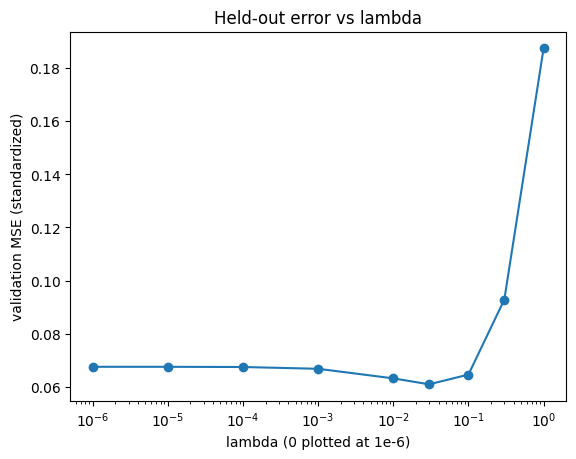

sigma_train = 0.3172 standardized units (3.5% of mean load)


In [8]:
# TODO (students): select lambda on held-out error rather than accepting this value.
# Hold out the last two weeks of the training window, or use an Optuna search as the SGD page does.
# Time-ordered validation: hold out the last 14 days of the training window
cut = train.index.max() - pd.Timedelta(days=14)
m = train.index <= cut
Xa, Xb = X_train[m], X_train[~m]
ya_raw, yb_raw = y_train_raw[m], y_train_raw[~m]

# scalers fitted on the sub-training part only (no peeking at validation)
mu_a, sd_a = Xa.mean(0), Xa.std(0) + 1e-9
ym_a, ys_a = ya_raw.mean(), ya_raw.std()
Xa_s, Xb_s = (Xa - mu_a) / sd_a, (Xb - mu_a) / sd_a
ya, yb = (ya_raw - ym_a) / ys_a, (yb_raw - ym_a) / ys_a

lambdas = [0, 1e-5, 1e-4, 1e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1]
val = {}
for lam in lambdas:
    th = sgd_fit(Xa_s, ya, lam)
    val[lam] = np.mean((Xb_s @ th - yb) ** 2)
    print(f"lambda={lam:<8g} val MSE={val[lam]:.4f}")

lambda_star = min(val, key=val.get)
print("chosen lambda:", lambda_star)

plt.semilogx([l if l > 0 else 1e-6 for l in lambdas], list(val.values()), "o-")
plt.xlabel("lambda (0 plotted at 1e-6)"); plt.ylabel("validation MSE (standardized)")
plt.title("Held-out error vs lambda"); plt.show()

theta = sgd_fit(standardize(X_train), y_train, lambda_star)

train_resid = standardize(X_train) @ theta + y_bar - y_train
sigma_train = train_resid.std()
print(f"sigma_train = {sigma_train:.4f} standardized units "
      f"({sigma_train * y_std / y_mean * 100:.1f}% of mean load)")

Report the spread of the training residuals before evaluating either new window.

Do not use the training residual spread to set the detector threshold. It is likely to be smaller than
the residual spread on unseen data. Calibrate the threshold on the control window and report the difference
in Part 4.

## Part 3: freeze and apply

Keep the fitted weights and both training scalers fixed when evaluating the other windows.

Do not refit the model on the control or event data.

Do not calculate new scaling statistics for either evaluation window. The provided function
applies the training statistics and fitted weights.


In [9]:
def apply_frozen(df, X):
    """Apply the frozen model to a window. Positive residual means the model over-predicted."""
    out = df.copy()
    y_true = z(out["load"].to_numpy())                 # training scaler
    y_pred = standardize(X) @ theta + y_bar            # training weights and feature scaler
    out["y_true"], out["y_pred"] = y_true, y_pred
    out["resid"] = y_pred - y_true
    return out


control_r = apply_frozen(control, X_control)
event_r = apply_frozen(event, X_event)

# Calibrate on unseen ordinary data, not on the training residuals.
sigma_control = control_r["resid"].std()
print(f"sigma_train   = {sigma_train:.4f}   (days the model was fitted to)")
print(f"sigma_control = {sigma_control:.4f}   (unseen ordinary days)")
print(f"ratio         = {sigma_control / sigma_train:.2f}")

# y_true and y_pred are standardized; resid is y_pred - y_true, so positive means over-prediction
event_r.head()

sigma_train   = 0.3172   (days the model was fitted to)
sigma_control = 0.5749   (unseen ordinary days)
ratio         = 1.81


,load,temp,hour,dow,y_true,y_pred,resid
t,,,,,,,
2021-02-14 00:00:00-06:00,54661.583333,26.9750,0,6,3.115874,2.651730,-0.464144
2021-02-14 01:00:00-06:00,54355.666667,26.6125,1,6,3.047034,2.288408,-0.758626
2021-02-14 02:00:00-06:00,54459.333333,26.0375,2,6,3.070362,2.345067,-0.725295
2021-02-14 03:00:00-06:00,54887.500000,25.8500,3,6,3.166711,2.444275,-0.722437
2021-02-14 04:00:00-06:00,55680.583333,25.4375,4,6,3.345177,2.901550,-0.443627


## Part 4: compare the windows

Report the mean squared error of the frozen model on the control and event windows. Express both relative to the training residual spread.

Also report the ratio of control to training residual spread. This quantifies the difference between
in-sample and out-of-sample error.

The control window immediately precedes the event and includes the beginning of the cold weather. Discuss
whether the two error distributions separate, using the values you calculate.


In [10]:
print(f"y_std = {y_std:,.0f} MW   (1.0 standardized unit)\n")

def window_stats(r, name):
    mse = (r["resid"] ** 2).mean()
    print(f"{name:8} MSE = {mse:.4f}   MSE/sigma_train^2 = {mse / sigma_train**2:6.2f}"
          f"   RMSE/sigma_train = {np.sqrt(mse) / sigma_train:5.2f}"
          f"   RMSE ≈ {np.sqrt(mse) * y_std:,.0f} MW"
          f"   mean resid = {r['resid'].mean():+.3f}")

window_stats(control_r, "control")
window_stats(event_r, "event")

daily = pd.DataFrame({
    "MSE / sigma_train^2": pd.concat([
        control_r["resid"].pow(2).groupby(control_r.index.date).mean(),
        event_r["resid"].pow(2).groupby(event_r.index.date).mean(),
    ]) / sigma_train**2,
    "mean resid": pd.concat([
        control_r["resid"].groupby(control_r.index.date).mean(),
        event_r["resid"].groupby(event_r.index.date).mean(),
    ]),
})
daily["window"] = ["control"] * control_r.index.normalize().nunique() + ["event"] * event_r.index.normalize().nunique()
print("\nPer day:")
print(daily.round(2))

y_std = 4,444 MW   (1.0 standardized unit)

control  MSE = 0.6124   MSE/sigma_train^2 =   6.09   RMSE/sigma_train =  2.47   RMSE ≈ 3,478 MW   mean resid = -0.533
event    MSE = 25.8355   MSE/sigma_train^2 = 256.75   RMSE/sigma_train = 16.02   RMSE ≈ 22,588 MW   mean resid = +4.020

Per day:
            MSE / sigma_train^2  mean resid   window
2021-02-08                 0.41       -0.13  control
2021-02-09                 5.85       -0.67  control
2021-02-10                 8.95       -0.91  control
2021-02-11                 6.31       -0.68  control
2021-02-12                 9.08       -0.60  control
2021-02-13                 5.91       -0.21  control
2021-02-14                35.45        1.22    event
2021-02-15               733.69        8.30    event
2021-02-16               571.85        7.27    event
2021-02-17               103.93        3.18    event
2021-02-18                45.03        2.07    event
2021-02-19                50.55        2.08    event


## Part 5: signed residuals

Use signed residuals to examine the direction of the model error.

Plot the signed residual over time for both windows. Then answer: during the shedding on 15 and 16
February, does the model predict too much load or too little? Explain the direction in terms of what the
model was given as input and what ERCOT was doing at the time, and say what that residual represents
physically.

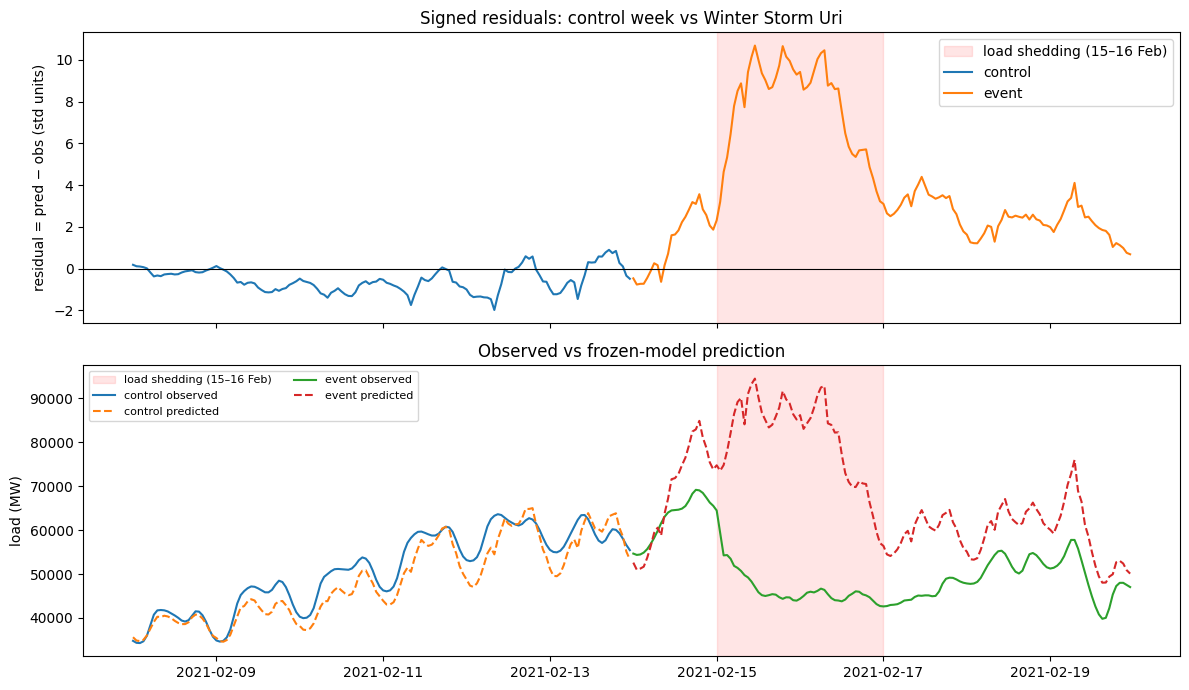

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
tz = event_r.index.tz
for ax in (ax1, ax2):
    ax.axvspan(pd.Timestamp("2021-02-15", tz=tz), pd.Timestamp("2021-02-17", tz=tz),
               color="red", alpha=0.1, label="load shedding (15–16 Feb)")

for name, r in [("control", control_r), ("event", event_r)]:
    ax1.plot(r.index, r["resid"], label=name)
    ax2.plot(r.index, r["y_true"] * y_std + y_mean, label=f"{name} observed")
    ax2.plot(r.index, r["y_pred"] * y_std + y_mean, "--", label=f"{name} predicted")

ax1.axhline(0, color="k", lw=0.8)
ax1.set_ylabel("residual = pred − obs (std units)")
ax1.set_title("Signed residuals: control week vs Winter Storm Uri")
ax1.legend()
ax2.set_ylabel("load (MW)")
ax2.set_title("Observed vs frozen-model prediction")
ax2.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

## Part 6: build the detector

The detector labels an hour as unusual when the size of its residual is above a threshold:

$$\text{flag}(t) = \mathbb{1}\left[\,\lvert r(t) \rvert > k\,\sigma_{\text{control}}\,\right]$$

Here $\sigma_{\text{control}}$ is the spread of the residuals during the ordinary control week. The number
$k$ controls how sensitive the detector is. A smaller $k$ flags more hours. A larger $k$ flags fewer hours.

A **false alarm** happens when the detector flags an hour in the control week even though that week is being
treated as normal. The **false-alarm rate** is the fraction of control hours that are flagged. For example,
if 6 of 100 control hours are flagged, the false-alarm rate is 6%.

Try several values of $k$. For each value, report the percentage of control hours and event hours that are
flagged. Choose a value that keeps the control percentage reasonably low while still identifying event hours.

The same control week is used here to calculate $\sigma_{\text{control}}$ and to count false alarms, so the
result applies only to this sample. A larger study would use separate ordinary weeks to choose and evaluate
the threshold.

Finally, consider duration. One unusual hour may be noise, while several unusual hours in a row provide
stronger evidence of an event. Briefly describe how consecutive flags could improve the detector.

In [12]:
ks = [1, 1.5, 2, 2.5, 3, 4, 5]
rows = []
for k in ks:
    thr = k * sigma_control
    rows.append({"k": k,
                 "threshold (std)": thr,
                 "control flagged %": 100 * (control_r["resid"].abs() > thr).mean(),
                 "event flagged %":   100 * (event_r["resid"].abs() > thr).mean()})
print(pd.DataFrame(rows).round(2).to_string(index=False))

# Duration: keep only flags that belong to a run of >= min_run consecutive hours
def persistent(flags, min_run=3):
    run_id = (flags != flags.shift()).cumsum()
    run_len = flags.groupby(run_id).transform("size")
    return flags & (run_len >= min_run)

print("\nWith a 3-hour persistence rule:")
rows = []
for k in ks:
    thr = k * sigma_control
    rows.append({"k": k,
                 "control flagged %": 100 * persistent(control_r["resid"].abs() > thr).mean(),
                 "event flagged %":   100 * persistent(event_r["resid"].abs() > thr).mean()})
print(pd.DataFrame(rows).round(2).to_string(index=False))

  k  threshold (std)  control flagged %  event flagged %
1.0             0.57              59.03            95.83
1.5             0.86              31.25            90.97
2.0             1.15              15.97            88.89
2.5             1.44               2.78            85.42
3.0             1.72               1.39            81.25
4.0             2.30               0.00            68.06
5.0             2.87               0.00            49.31

With a 3-hour persistence rule:
  k  control flagged %  event flagged %
1.0              56.94            95.14
1.5              29.86            90.97
2.0              15.28            88.19
2.5               0.00            85.42
3.0               0.00            79.86
4.0               0.00            68.06
5.0               0.00            49.31


## Part 7: write up

Answer the questions in the Markdown cells below. Replace each placeholder with your answer. Refer to the
numbers, plots, and tables you produced above. Do not write a separate README.

### 1. How accurate is the baseline?

Report sigma_train, sigma_control, and their ratio. What does the difference tell you?

**Answer:** σ_train = 0.317 (about 1.4 GW, 3.5% of mean load) and σ_control = 0.575, a ratio of 1.81. Training error is optimistic because the model was fitted on those hours. The control week also dipped below the training temperature range (26 F vs. 29 F), and the model under-predicted it on average: every day's mean residual was negative, and the overall mean was −0.53. That is why the threshold is calibrated on control rather than on training residuals.

### 2. Does the storm week look different?

Compare the control and event errors. State whether the residuals separate the two weeks and cite your
results.

**Answer:** Yes. The event MSE is 256.75 σ_train², compared with 6.09 for the control week, about 42× larger. No day overlaps: the worst control day (9.08) is below the mildest event day (35.45). The error peaks on Feb 15–16 (733.69 and 571.85), matching the shedding.

### 3. What happened during load shedding?

On 15 and 16 February, were the residuals mostly positive or negative? Explain what that sign means in terms
of predicted and observed load.

**Answer:** The residuals were strongly positive, meaning the model over-predicted. They peaked at +10.68 (about 47.5 GW) at 11:00 on Feb 15. The model saw temperatures near 9 F and predicted up to 94.5 GW of demand. ERCOT was cutting power, so observed load averaged only 46.9 GW over Feb 15–16. The residual approximates unserved demand, but it is inflated by extrapolation. At the pre-shedding peak (18:00 on Feb 14), observed load was 69.2 GW and predicted was 83.0 GW, a residual of +3.10 (about 13.8 GW) with no shedding yet.

### 4. How did your detector perform?

State the value of k you chose. Report the percentage of control hours and event hours that it flagged. The
control percentage is the false-alarm rate for this exercise.

**Answer:** With k = 2.5, the detector flagged 2.78% of control hours (the false-alarm rate) and 85.42% of event hours. Going from k = 2 to 2.5 cut false alarms from 16% to 2.8% at little cost to detection. The rates are optimistic, because the same control week was used both to set the threshold and to evaluate it.

### 5. What else could cause a large residual?

Give one normal situation that this model might flag and explain how you could distinguish it from a grid
event.

**Answer:** A holiday. The model has no holiday feature, so it over-predicts, which produces a positive residual just like shedding. A holiday can be told apart because it is known in advance, it keeps a normal daily load shape, it is much smaller in magnitude, and it lasts only one day.

### 6. How could duration improve the detector?

Explain how you would use several flagged hours in a row instead of treating every hour separately.

**Answer:** Only raise an alarm when several consecutive hours are flagged. A 3-hour rule at k = 2.5 cut control false alarms from 2.78% to 0% while event detection stayed at 85.42%. Real failures persist, while noise doesn't. The cost is a few hours of delay before the alarm fires.

## Submitting

Follow the [assignment submission guide](https://aegean.ai/aiml-common/resources/environment/assignment-submission). Commit
this notebook with all cell outputs saved, and submit the complete GitHub URL of its directory.